In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우: 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False 

In [3]:
df1 = pd.read_csv("dataset/tournum23.csv", encoding="utf-8")
df2 = pd.read_csv("dataset/tournum24.csv", encoding="utf-8")
df3 = pd.read_csv("dataset/tourfrom23.csv", encoding="utf-8")
df4 = pd.read_csv("dataset/tourfrom24.csv", encoding="utf-8")


In [4]:
# df1과 df2를 그대로 합치기
# df2의 컬럼명을 df1과 맞춤
df2.columns = df1.columns

# df1과 df2를 연결
df_tournum = pd.concat([df1, df2], ignore_index=True)
pd.set_option('display.max_columns', None)
print(df_tournum)

     지역     방문자 수   기준년월일
0   성동구   61194.0  202301
1   성동구   70453.0  202302
2   성동구   73831.0  202303
3   성동구  183171.0  202304
4   성동구  178694.0  202305
5   성동구  171773.0  202306
6   성동구  171280.0  202307
7   성동구  186658.0  202308
8   성동구  194469.0  202309
9   성동구  224162.0  202310
10  성동구  200732.0  202311
11  성동구  179820.0  202312
12  성동구  145583.0  202401
13  성동구  157270.0  202402
14  성동구  225617.0  202403
15  성동구  254897.0  202404
16  성동구  219151.0  202405
17  성동구  212983.0  202406
18  성동구  215214.0  202407
19  성동구  231696.0  202408
20  성동구  255219.0  202409
21  성동구  329127.0  202410
22  성동구  261366.0  202411
23  성동구  240416.0  202412


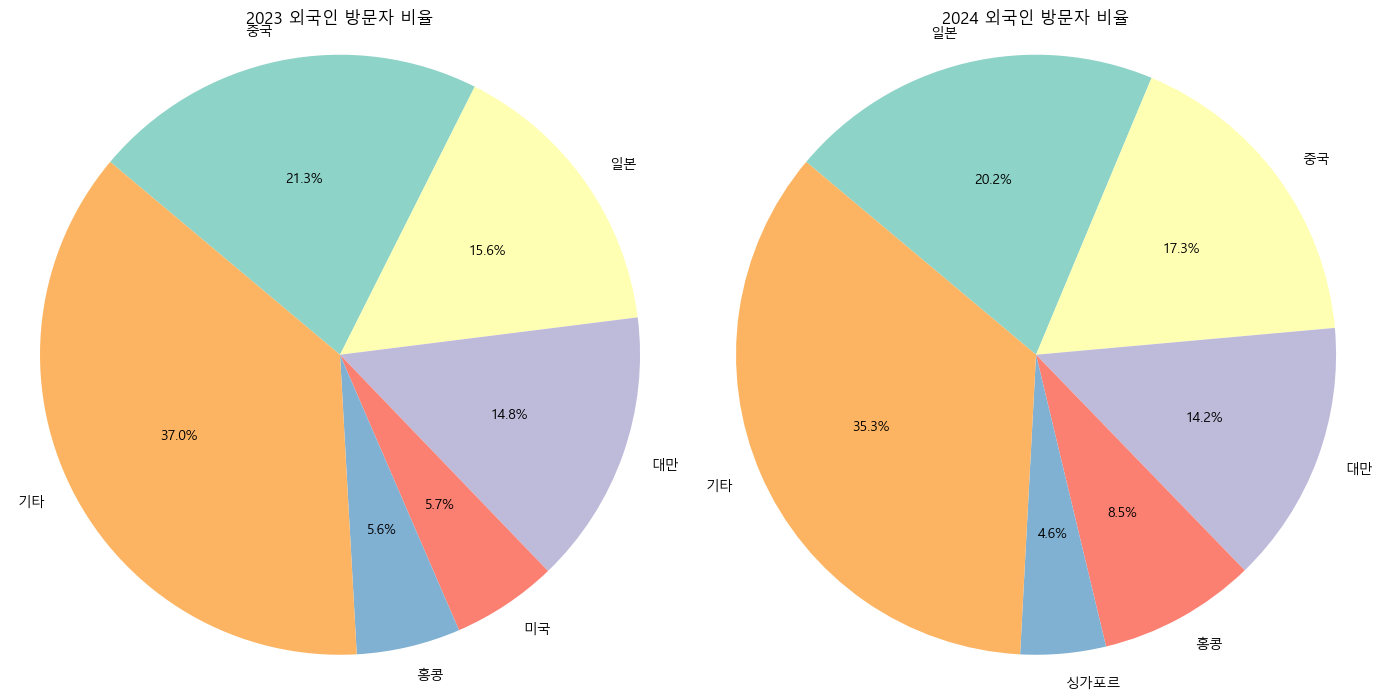

In [13]:
def top5_plus_recomputed_others(df, label_col="국가", value_col="방문자 비율", etc_label="기타"):
    # 1) 값 내림차순 정렬
    df_sorted = df.sort_values(value_col, ascending=False).reset_index(drop=True)

    # 2) '기타' 제외 후 상위 5개
    top5 = df_sorted[df_sorted[label_col] != etc_label].head(5)

    # 3) 상위 5개를 제외한 나머지(기존 '기타' 포함) 모두 합산해 새 '기타' 생성
    rest_sum = df_sorted[~df_sorted[label_col].isin(top5[label_col])][value_col].sum()
    others = pd.DataFrame({label_col: [etc_label], value_col: [rest_sum]})

    # 4) 결합
    return pd.concat([top5, others], ignore_index=True)

# 가공
data_2023 = top5_plus_recomputed_others(df3)
data_2024 = top5_plus_recomputed_others(df4)

# 보기 좋은 컬러 팔레트 (Set3)
colors = plt.cm.Set3.colors

# 나란히 출력
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].pie(data_2023["방문자 비율"],
            labels=data_2023["국가"],
            autopct="%.1f%%",
            startangle=140,
            counterclock=False,
            colors=colors)
axes[0].set_title("2023 외국인 방문자 비율")
axes[0].axis('equal')

axes[1].pie(data_2024["방문자 비율"],
            labels=data_2024["국가"],
            autopct="%.1f%%",
            startangle=140,
            counterclock=False,
            colors=colors)
axes[1].set_title("2024 외국인 방문자 비율")
axes[1].axis('equal')

plt.tight_layout()
plt.show()

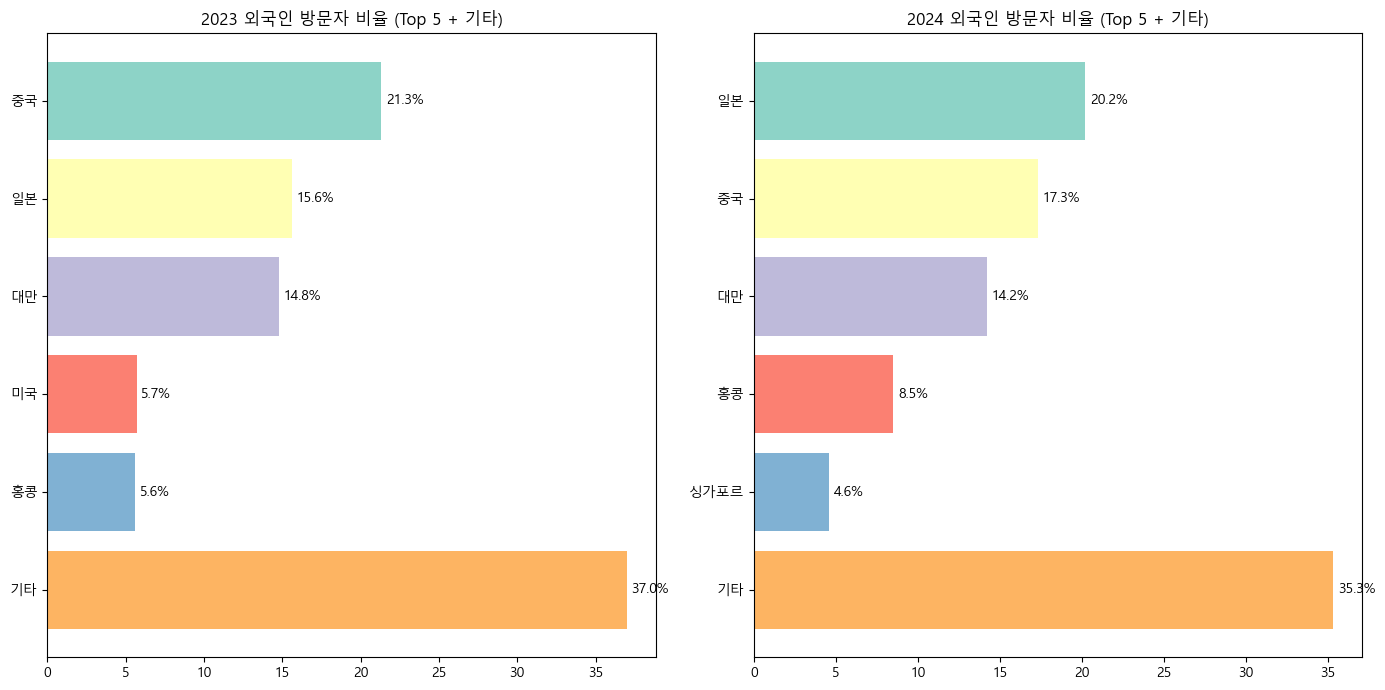

In [14]:
def top5_plus_recomputed_others(df, label_col="국가", value_col="방문자 비율", etc_label="기타"):
    # 1) 값 내림차순 정렬
    df_sorted = df.sort_values(value_col, ascending=False).reset_index(drop=True)

    # 2) '기타' 제외 후 상위 5개
    top5 = df_sorted[df_sorted[label_col] != etc_label].head(5)

    # 3) 상위 5개를 제외한 나머지(기존 '기타' 포함) 합산
    rest_sum = df_sorted[~df_sorted[label_col].isin(top5[label_col])][value_col].sum()
    others = pd.DataFrame({label_col: [etc_label], value_col: [rest_sum]})

    # 4) 결합
    return pd.concat([top5, others], ignore_index=True)

# 데이터 가공
data_2023 = top5_plus_recomputed_others(df3)
data_2024 = top5_plus_recomputed_others(df4)

# 색상 팔레트
colors = plt.cm.Set3.colors

# ---------- Subplot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 2023 barh
axes[0].barh(data_2023["국가"], data_2023["방문자 비율"], color=colors)
axes[0].set_title("2023 외국인 방문자 비율 (Top 5 + 기타)")
axes[0].invert_yaxis()  # 가장 큰 값이 위로 오도록
for i, v in enumerate(data_2023["방문자 비율"]):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va='center')

# 2024 barh
axes[1].barh(data_2024["국가"], data_2024["방문자 비율"], color=colors)
axes[1].set_title("2024 외국인 방문자 비율 (Top 5 + 기타)")
axes[1].invert_yaxis()
for i, v in enumerate(data_2024["방문자 비율"]):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()